## PyTorch workflow

1. data (prepare and load)
2. build model
3. fitting the model to data (training)
4. making predictions and evaluating a model (inference)
5. saving and loading a model
6. putting it all together

> Blok alıntı ekle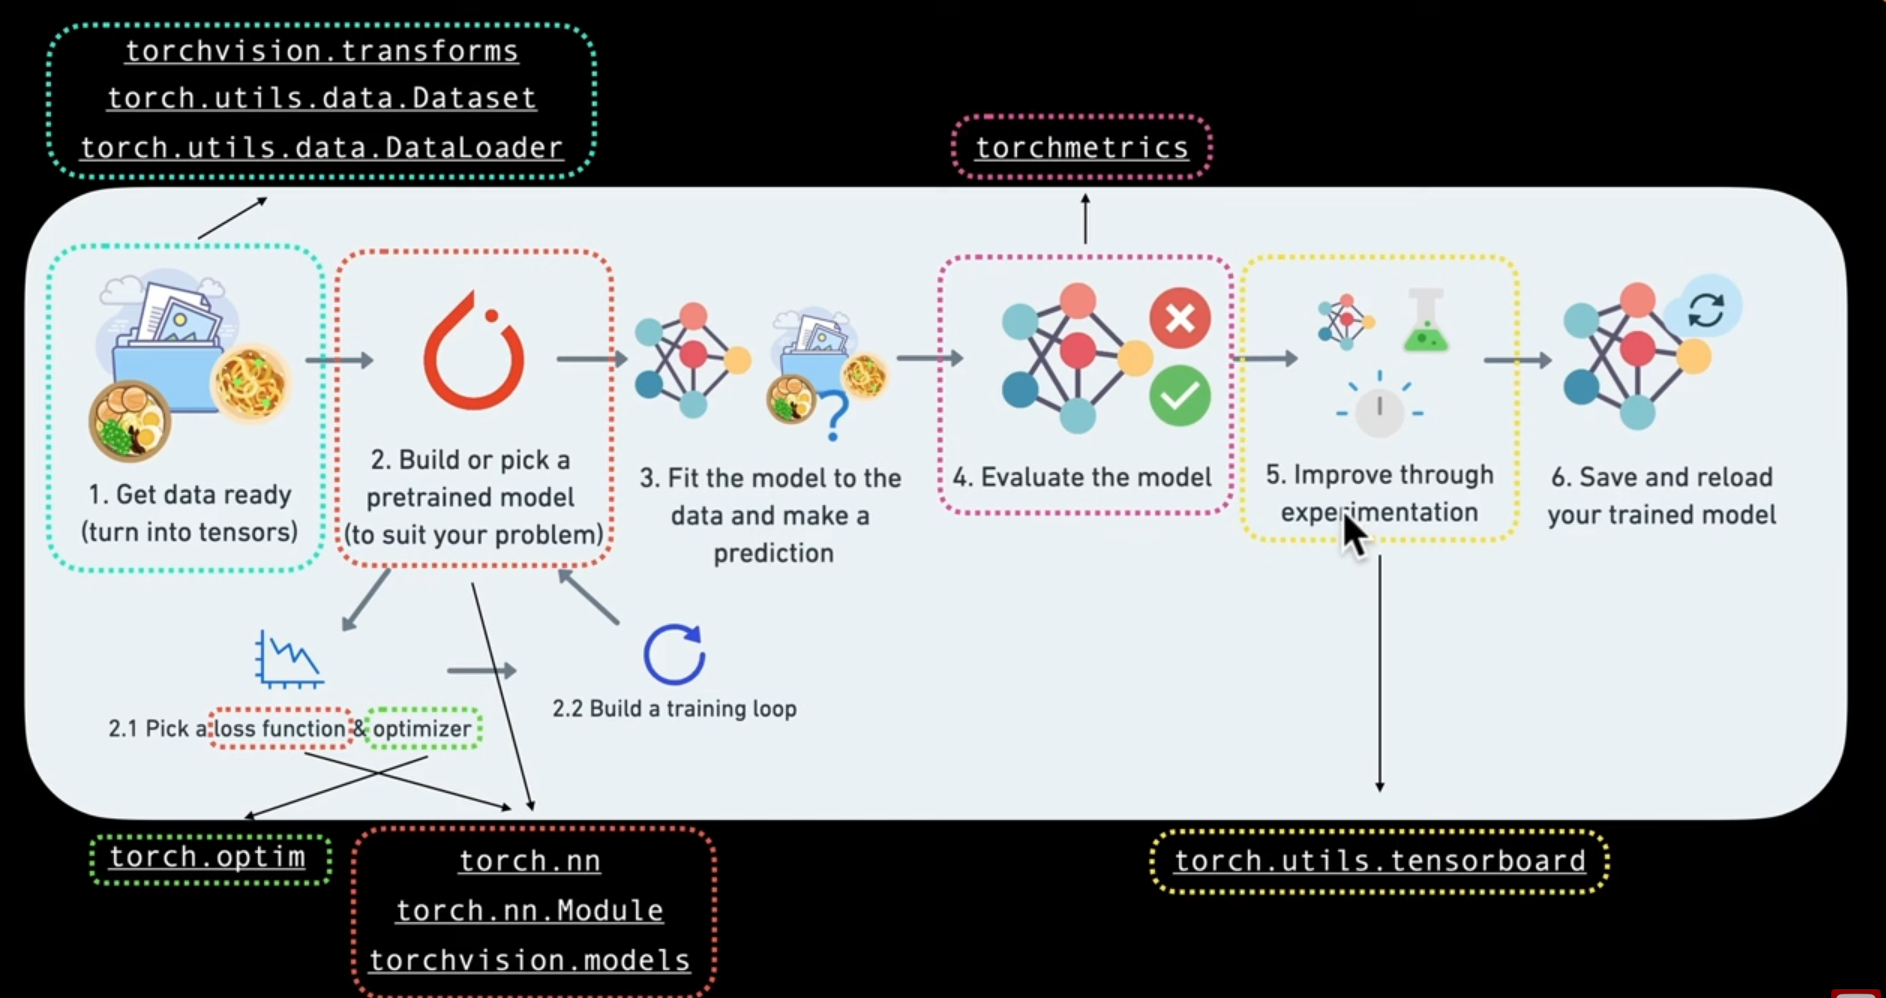



In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.9.0+cpu'

## 1. Data (preparing and loading)

Machine learning in two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representations

To showcase this, let's create some *known* data using linear regression formula (a + bX)

We'll use a linear regression formula to make a straight line with *known* **parameters** .

In [ ]:
# create known parameters
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) #adding one more []
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

# Splitting data into training and test sets (one of the most important concepts in ml in general)

Three datasets:
1. Course materials (training set) - model learns patterns from here

2. Practice exam (validation set) - tune model patterns, not always used

3. Final exam (test set) - see if the model is ready for the wild

In [ ]:
train_split = int(0.8 *  len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
# data visualization
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(5,3))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size":14})


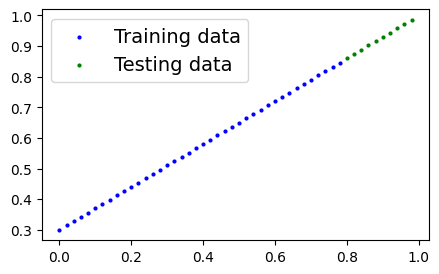

In [ ]:
plot_predictions()

## PyTorch model

What our model does:

* Start with random values
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data).

How does it do so?
1. Gradient descent
2. Backpropagation

`requires_grad=True` means PyTorch will track the gradients of this specific parameter for use with `torch.autograd` and gradient descent (for many `torch.nn` modules, `requires_grad=True` is set by default)

In [ ]:
from torch import nn
import torch

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor: #x: torch.Tensor = giriş tipi, -> return type
    return self.weights * x + self.bias # linear regression formula

### PyTorch model building essentials

* torch.nn -contains all of the buildings for computational graphs (neural networks)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - the base class for all neural network modules, if you subclass it, yoy should owerwrite forward()
* torch.optim - this is where optimizers in pytorch live, they will help with gradient descent (these tell the model parameters stored in `nn.Parameter` how to best change to improve gradient descent and it turn reduce the loss)
* torch.utils.data.Dataset - Represents a map between key (label) and sample (features) pairs of your data. Such as images and their associated labels.
* torch.utils.data.DataLoader - Creates a python iterable over a torch Dataset (allows you to iterate over your data)

In [ ]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

To check out model's predictive power, let's see how well it predict `y_test` based on `x_test`.

When we pass data through out model, it's going to run through the `forward()` method.

In [ ]:
# gradient descent gibi şeyler olmadan sadece forward propagation ile test aşamasında bir tahmin yapmak gibi bir şeyler
with torch.inference_mode(): # preferred
  y_preds = model_0(X_test)

# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

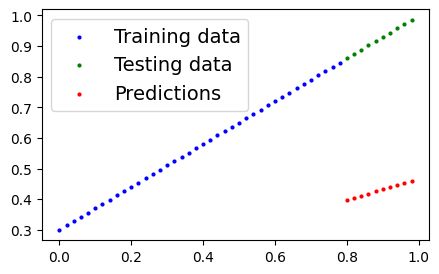

In [ ]:
plot_predictions(predictions=y_preds)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

Or in the other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models prediction are to use a loss function.

Things we need to train:

* Note: Loss function may also be called cost function or cirterion in different areas.

* **Loss function** : A function to measure how wrong your model's predictions are to th eideal outputs, lower is better.

* **Optimizer** : Takes into account the loss of a model an adjusts the model's parameters (e.g weight, bias in our case) to improve the loss funciton.

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [ ]:
print(list(model_0.parameters()))
model_0.state_dict()

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Mean absolute error (MAE) for regression problem
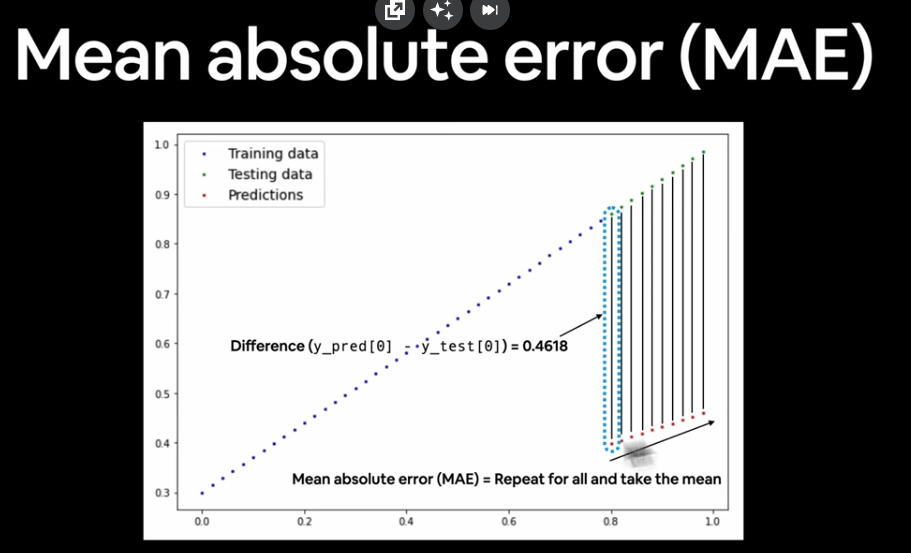
* `MAE_loss = torch.mean(torch.abs(y_pred - y_test))`

* `MAE_loss = torch.nn.L1Loss`

But for a classificaiton problem -> `nn.BCELoss()` (binary cross entropy loss)

In [ ]:
# setup an a loss function
loss_fn = torch.nn.L1Loss() # MAE for regression problems
# setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # learning rate (default 0.01 with sgd) : possibly the most important hyperparameter you can set

### Building a training loop and a testing loop

0. Loop through the data
1. Forward pass (this involves data moving through out model's `forward()` functions) to make predictions on data  - forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Oprimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of out model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

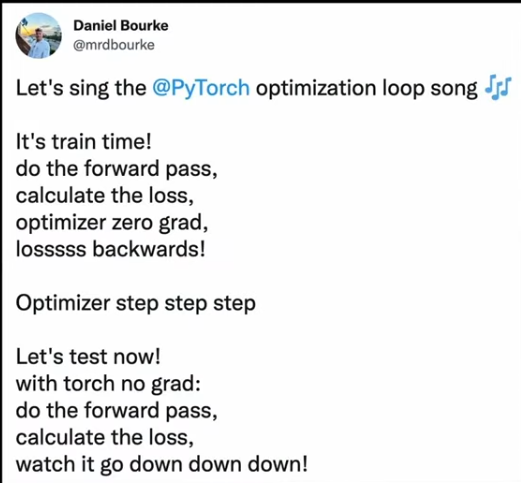

In [ ]:
epochs = 200 # an epoch is one loop through the data (this is a hyperparameter, we've set it )

epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
for epoch in range(epochs):
  # set the model to training mode
  model_0.train()

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grads
  optimizer.zero_grad()

  # 4. Perfrom backpropagation
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  # by default how the optimizer changes will accumulate through the loop, so we have to zero them above in step 3 for the next iteration of the loop
  optimizer.step()



  ### Testing
  model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropuout, batch norm layers)
  with torch.inference_mode(): # turns off gradient descent and a couple of more things behind the scenes
  # with torch.no_grad(): # you may also see in older pytorch code

    #1 Do the forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
    print(model_0.state_dict())



Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

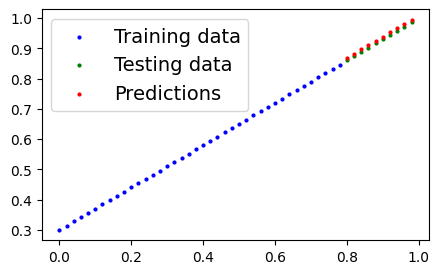

In [ ]:
plot_predictions(predictions=test_pred)

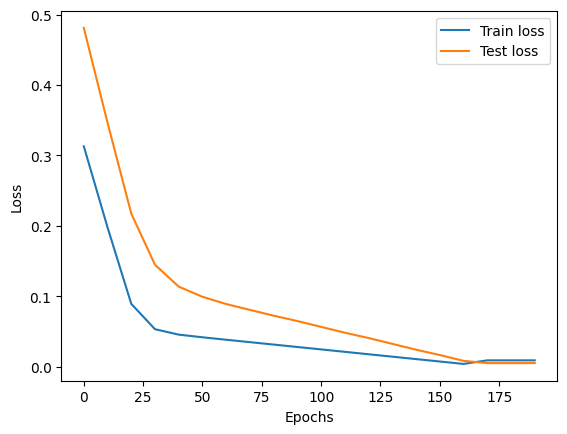

In [ ]:
import numpy as np

# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## Saving and loading methods

There are three main methods in PyTorch:
1. `torch.save()` - allows you save a pytorch object in Python's pickle format
2. `torch.load()` - allows you load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

Bütün modeli de kaydedebilirsin sadece state_dict() de kaydedebilirsin (önerilen)

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH =  MODEL_PATH / MODEL_NAME

#3.Save the model state dict
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)



In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Feb 10 13:33 01_pytorch_workflow_model_0.pth


In [ ]:
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,   # also called dense layer, fully connected layer
                                  out_features=1)
    # self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    # self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)
    # return self.weights * x + self.bias

## EXERCISES

In [2]:
import torch
import numpy
import matplotlib.pyplot as plt
from torch import nn

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [10]:
weight = 0.3
bias = 0.9

X = torch.arange(0,1, 0.01).unsqueeze(dim=1)
y = weight * X + bias

train_split = int(len(X) * 0.8)
x_train = X[:train_split]
y_train = y[:train_split]
x_test = X[train_split:]
y_test = y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(80, 80, 20, 20)

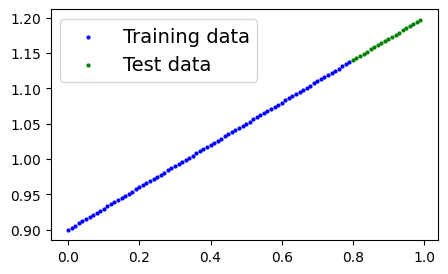

In [11]:
def plot_predictions(train_data = X_train,
                 train_labels = y_train,
                 test_data = X_test,
                 test_labels = y_test,
                 predictions = None ):
  plt.figure(figsize = (5,3))
  plt.scatter(train_data,train_labels,c = 'b',s = 4,label = "Training data")
  plt.scatter(test_data,test_labels,c = 'g',s = 4,label = "Test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c = 'r',s = 4,label = "Predictions")
  plt.legend(prop = {"size" : 14})
plot_predictions()

In [15]:
class LinearModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(data=torch.randn(1,
                                              requires_grad=True,
                                              dtype=torch.float
                                              ))

    self.bias = nn.Parameter(data=torch.randn(1,
                                              requires_grad=True,
                                              dtype=torch.float
                                              ))

  def forward(self, x : torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias

torch.manual_seed(42)

model = LinearModel()
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
next(model.parameters()).device

device(type='cpu')

In [18]:
model.to(device)
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [22]:
loss_func = nn.L1Loss()
opt = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [26]:
torch.manual_seed(42)
epochs = 300
# Send data to target device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
   model.train()
   y_pred = model(x_train)
   loss = loss_func(y_pred, y_train)
   opt.zero_grad()
   loss.backward()
   opt.step()

   if epoch % 20 == 0:
    y_preds = model(x_test)
    test_loss = loss_func(y_preds, y_test)
    print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.757 | Test loss: 0.725
Epoch: 20 | Train loss: 0.525 | Test loss: 0.454
Epoch: 40 | Train loss: 0.294 | Test loss: 0.183
Epoch: 60 | Train loss: 0.077 | Test loss: 0.073
Epoch: 80 | Train loss: 0.053 | Test loss: 0.116
Epoch: 100 | Train loss: 0.046 | Test loss: 0.105
Epoch: 120 | Train loss: 0.039 | Test loss: 0.089
Epoch: 140 | Train loss: 0.032 | Test loss: 0.074
Epoch: 160 | Train loss: 0.025 | Test loss: 0.058
Epoch: 180 | Train loss: 0.018 | Test loss: 0.042
Epoch: 200 | Train loss: 0.011 | Test loss: 0.026
Epoch: 220 | Train loss: 0.004 | Test loss: 0.009
Epoch: 240 | Train loss: 0.004 | Test loss: 0.006
Epoch: 260 | Train loss: 0.004 | Test loss: 0.006
Epoch: 280 | Train loss: 0.004 | Test loss: 0.006


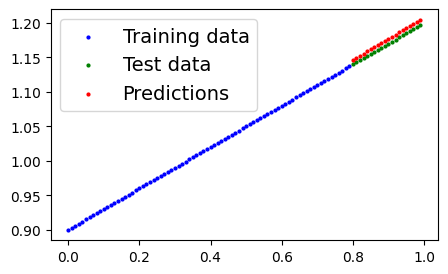

In [27]:
model.eval()

with torch.inference_mode():
  y_preds = model(x_test)

plot_predictions(predictions = y_preds.cpu())